Introduction: Movie Rating Prediction


The goal of this project is to analyze historical film data and develop a machine learning model that accurately estimates the rating given to a movie by users or critics.

Using Libraries:

pandas, numpy, sklearn, matplotlib

Import the pandas library for data manipulation.

In [2]:
import pandas as pd

Load the IMDb Movies India dataset into a DataFrame using pandas, with Latin-1 encoding, and display the first few rows.

In [3]:
df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


Remove rows from the DataFrame where the 'Rating' column has missing values.

In [4]:
df.dropna(subset = ['Rating'], inplace = True)

 Clean the 'Year' column by converting it to string, removing parentheses, and converting back to integer.

In [5]:
df['Year'] = df['Year'].astype(str).str.replace(r'\(|\)', '', regex=True).astype(int)

 Clean the 'Duration' column by removing 'min' and converting to float.

In [6]:
df['Duration'] = df['Duration'].str.replace(r'min', '', case=False).astype(float)

Clean the 'Votes' column by removing commas and converting to integer.

In [7]:
df['Votes'] = df['Votes'].str.replace(r',', '', case=False).astype(int)

Display the first few rows of the cleaned DataFrame.

In [8]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


Display the first few rows of the cleaned DataFrame.

In [9]:
def encode_target(df, column):
  mean_rating = df.groupby(column)['Rating'].mean().to_dict()
  df[column] = df[column].map(mean_rating)
  return df

Apply the encoding function to the 'Genre', 'Director', 'Actor 1', 'Actor 2', and 'Actor 3' columns, then display the first few rows.

In [10]:
df = encode_target(df, 'Genre')
df = encode_target(df, 'Director')
df = encode_target(df, 'Actor 1')
df = encode_target(df, 'Actor 2')
df = encode_target(df, 'Actor 3')

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,6.352082,7.0,8,7.000000,6.850000,7.000000,7.000000
3,#Yaaram,2019,110.0,5.722500,4.4,35,4.400000,5.420000,4.400000,4.450000
5,...Aur Pyaar Ho Gaya,1997,147.0,6.224490,4.7,827,5.358824,4.788889,5.786667,5.846154
6,...Yahaan,2005,142.0,6.820000,7.4,1086,7.500000,5.356000,6.050000,6.500000
8,?: A Question Mark,2012,82.0,5.463636,5.6,326,5.600000,5.600000,5.883333,5.600000


 Import train-test split from scikit-learn, select features for prediction, split the data into training and testing sets (80% train, 20% test).



In [11]:
from sklearn.model_selection import train_test_split

features = ['Year', 'Duration', 'Votes', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

X = df[features]
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Import RandomForestRegressor and metrics, train a random forest model on the training data, make predictions on test data, and print the R² score.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.8016359858122215


Import numpy and calculate mean squared error and root mean squared error, then print the results with an interpretation.

In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse:.4f}")
print(f"On average, the model is off by {rmse:.2f} stars.")

Mean Squared Error: 0.3688
On average, the model is off by 0.61 stars.


Create a DataFrame comparing actual vs. predicted ratings and display the first few rows.

In [14]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())

       Actual  Predicted
9456      3.3      3.300
14816     5.3      5.144
3213      5.7      5.070
3778      7.2      6.505
5775      3.5      3.507


Feature Importance Plot :
Creates a bar chart showing which features (like Year, Duration, Votes, etc.) have the most influence on predicting movie ratings, using the trained Random Forest model. 
It saves the plot as 'feature_importance.png'.

C:\Users\abdul\AppData\Local\Temp\ipykernel_20300\1169238373.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


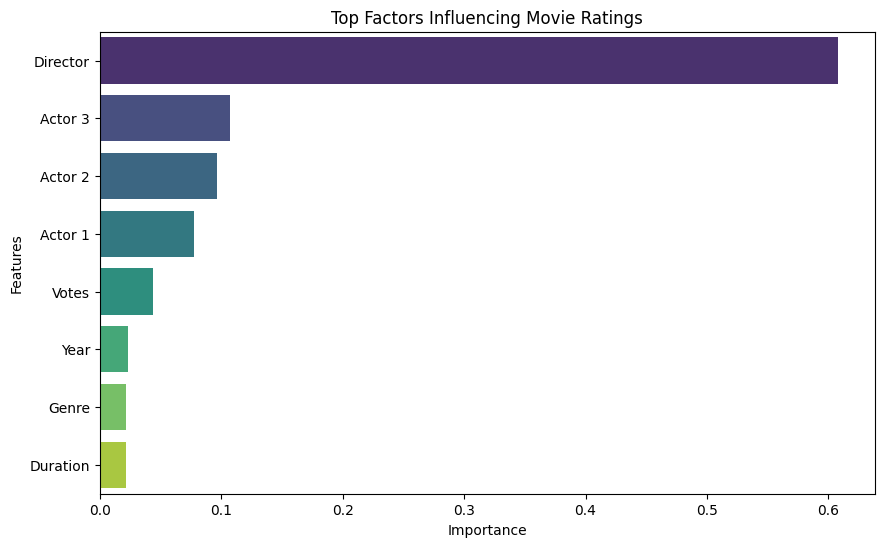

<Figure size 640x480 with 0 Axes>

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns

feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
plt.title('Top Factors Influencing Movie Ratings')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

plt.savefig('feature_importance.png')

Actual vs. Predicted Ratings Scatter Plot : Generates a scatter plot comparing the actual movie ratings from the test data against the model's predicted ratings. A red diagonal line shows perfect predictions. It saves the plot as 'actual_vs_predicted.png'.

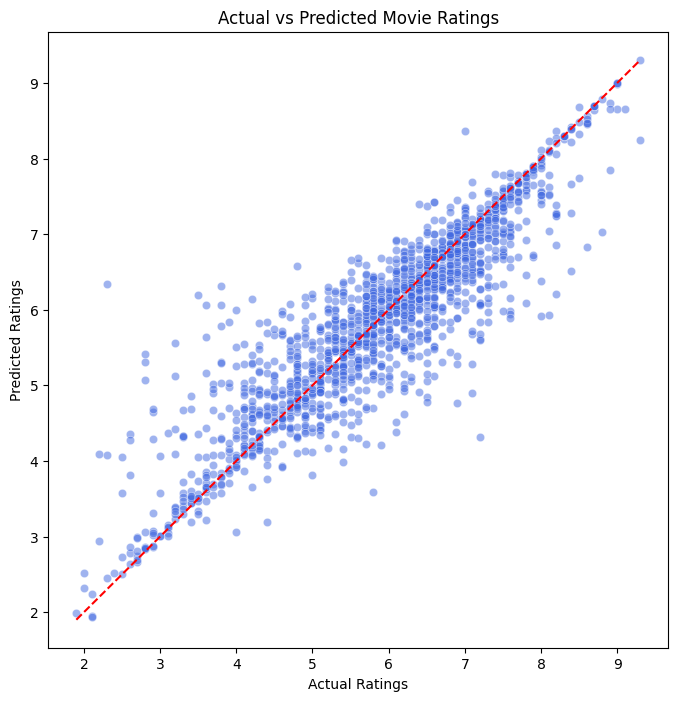

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Movie Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.show()

plt.savefig('actual_vs_predicted.png')

Residuals Distribution Plot : Calculates the differences (residuals) between actual and predicted ratings, then plots a histogram to show how the model's errors are distributed. A red vertical line marks zero error. It saves the plot as 'residuals_distribution.png'.



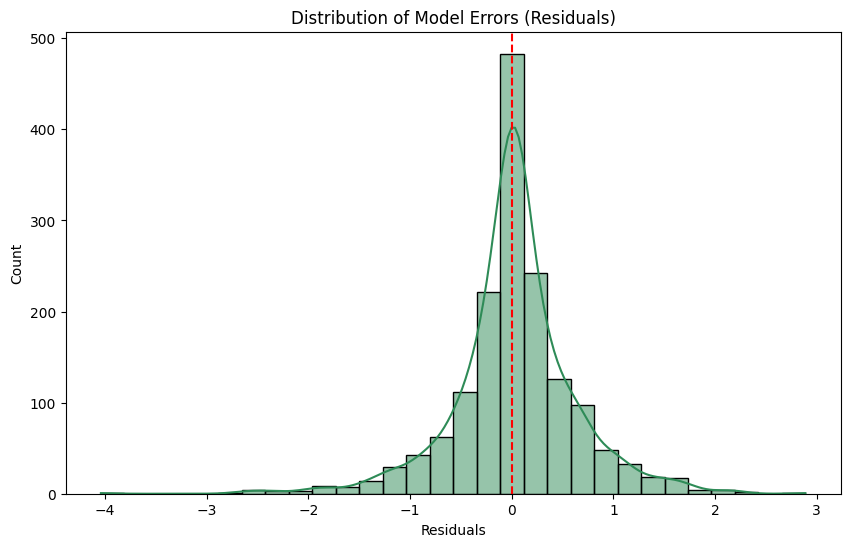

<Figure size 640x480 with 0 Axes>

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True, color='seagreen')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Model Errors (Residuals)')
plt.xlabel('Residuals')
plt.show()

plt.savefig('residuals_distribution.png')